# Taller 1 - Sistemas de Recomendacion 

ALISON DAIANA ARISTIZABAL GARCIA

SAMUEL CHARRY TOBAR

MARIA JOSE MANTILLA VARGAS

JERONIMO VASQUEZ PONCE

SANTIAGO PALACIOS LOAIZA - 202523012

In [3]:
import os
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import sklearn

# Configuración para gráficos
sns.set_style("whitegrid")
sns.set_palette("husl")

## 1. Exploracion del Dataset

In [4]:
# Ruta al directorio de datos
DAT_DIR = './dat'

# Carga de CSVs
tag = pd.read_csv(os.path.join(DAT_DIR, 'tag.csv'))
rating = pd.read_csv(os.path.join(DAT_DIR, 'rating.csv'))
movie = pd.read_csv(os.path.join(DAT_DIR, 'movie.csv'))
link = pd.read_csv(os.path.join(DAT_DIR, 'link.csv'))
genome_scores = pd.read_csv(os.path.join(DAT_DIR, 'genome_scores.csv'))
genome_tags = pd.read_csv(os.path.join(DAT_DIR, 'genome_tags.csv'))

# Resumen de carga
datasets = {'tag': tag, 'rating': rating, 'movie': movie, 'link': link, 'genome_scores': genome_scores, 'genome_tags': genome_tags}
for name, df in datasets.items():
    print(f"{name}: {len(df):,} filas, columnas: {list(df.columns)}")

tag: 465,564 filas, columnas: ['userId', 'movieId', 'tag', 'timestamp']
rating: 20,000,263 filas, columnas: ['userId', 'movieId', 'rating', 'timestamp']
movie: 27,278 filas, columnas: ['movieId', 'title', 'genres']
link: 27,278 filas, columnas: ['movieId', 'imdbId', 'tmdbId']
genome_scores: 11,709,768 filas, columnas: ['movieId', 'tagId', 'relevance']
genome_tags: 1,128 filas, columnas: ['tagId', 'tag']


### Estadísticas descriptivas (media, mediana, moda, desviación estándar)

In [5]:
# rating.csv - columna rating
print("=== rating (rating.csv) ===")
print(f"Media: {rating['rating'].mean():.4f}")
print(f"Mediana: {rating['rating'].median():.4f}")
print(f"Moda: {rating['rating'].mode().values}")
print(f"Desv. estándar: {rating['rating'].std():.4f}")
#print(rating['rating'].describe())

=== rating (rating.csv) ===
Media: 3.5255
Mediana: 3.5000
Moda: [4.]
Desv. estándar: 1.0520


In [6]:
# genome_scores.csv - columna relevance
print("=== relevance (genome_scores.csv) ===")
print(f"Media: {genome_scores['relevance'].mean():.4f}")
print(f"Mediana: {genome_scores['relevance'].median():.4f}")
print(f"Moda (valor más frecuente): {genome_scores['relevance'].mode().values}")
print(f"Desv. estándar: {genome_scores['relevance'].std():.4f}")
#print(genome_scores['relevance'].describe())

=== relevance (genome_scores.csv) ===
Media: 0.1165
Mediana: 0.0565
Moda (valor más frecuente): [0.014]
Desv. estándar: 0.1542


In [7]:
# Conteos por usuario y por película (actividad)
ratings_per_user = rating.groupby('userId').size()
ratings_per_movie = rating.groupby('movieId').size()

print("=== Ratings por usuario ===")
print(f"Media: {ratings_per_user.mean():.2f}")
print(f"Mediana: {ratings_per_user.median():.2f}")
print(f"Moda: {ratings_per_user.mode().values}")
print(f"Desv. estándar: {ratings_per_user.std():.2f}")

print("\n=== Ratings por película ===")
print(f"Media: {ratings_per_movie.mean():.2f}")
print(f"Mediana: {ratings_per_movie.median():.2f}")
print(f"Moda: {ratings_per_movie.mode().values}")
print(f"Desv. estándar: {ratings_per_movie.std():.2f}")

=== Ratings por usuario ===
Media: 144.41
Mediana: 68.00
Moda: [20]
Desv. estándar: 230.27

=== Ratings por película ===
Media: 747.84
Mediana: 18.00
Moda: [1]
Desv. estándar: 3085.82


In [8]:
# Categóricas: moda y frecuencias (tag, genres)
print("=== tag (tag.csv) - moda y top 5 ===")
print(tag['tag'].value_counts().head())

print("\n=== genres (movie.csv) - moda y top 5 ===")
print(movie['genres'].value_counts().head())

=== tag (tag.csv) - moda y top 5 ===
tag
sci-fi             3384
based on a book    3281
atmospheric        2917
comedy             2779
action             2657
Name: count, dtype: int64

=== genres (movie.csv) - moda y top 5 ===
genres
Drama            4520
Comedy           2294
Documentary      1942
Comedy|Drama     1264
Drama|Romance    1075
Name: count, dtype: int64


### Histogramas para sesgo (skew)

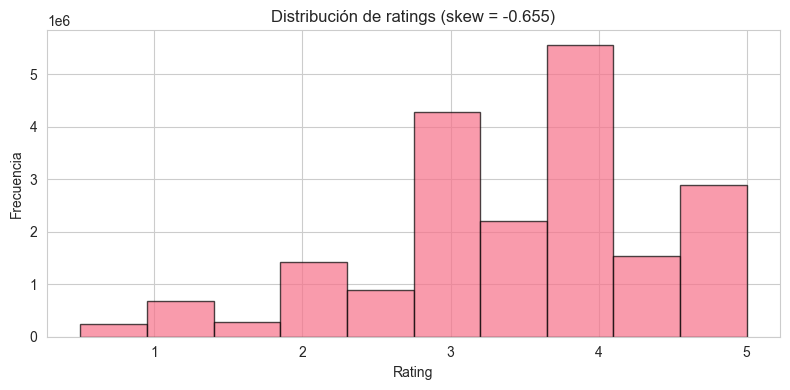

In [9]:
# Distribución de rating
skew_rating = stats.skew(rating['rating'])
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(rating['rating'], bins=10, edgecolor='black', alpha=0.7)
ax.set_xlabel('Rating')
ax.set_ylabel('Frecuencia')
ax.set_title(f'Distribución de ratings (skew = {skew_rating:.3f})')
plt.tight_layout()
plt.show()

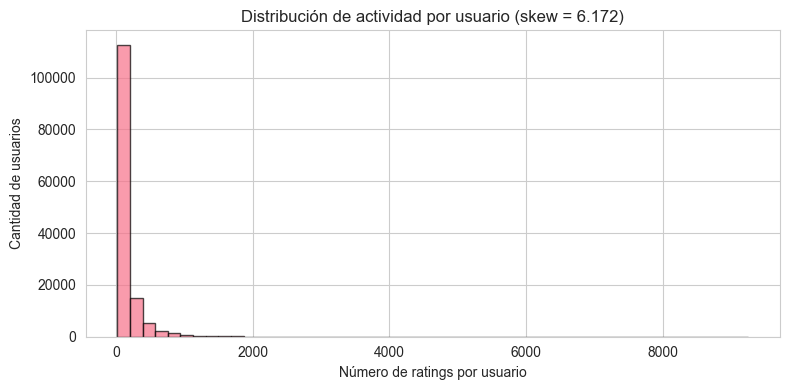

In [10]:
# Ratings por usuario (actividad)
skew_user = stats.skew(ratings_per_user)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ratings_per_user, bins=50, edgecolor='black', alpha=0.7)
ax.set_xlabel('Número de ratings por usuario')
ax.set_ylabel('Cantidad de usuarios')
ax.set_title(f'Distribución de actividad por usuario (skew = {skew_user:.3f})')
plt.tight_layout()
plt.show()

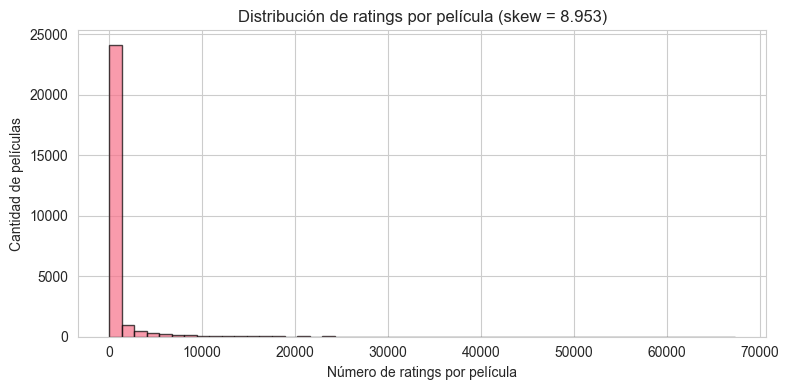

In [11]:
# Ratings por película
skew_movie = stats.skew(ratings_per_movie)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ratings_per_movie, bins=50, edgecolor='black', alpha=0.7)
ax.set_xlabel('Número de ratings por película')
ax.set_ylabel('Cantidad de películas')
ax.set_title(f'Distribución de ratings por película (skew = {skew_movie:.3f})')
plt.tight_layout()
plt.show()

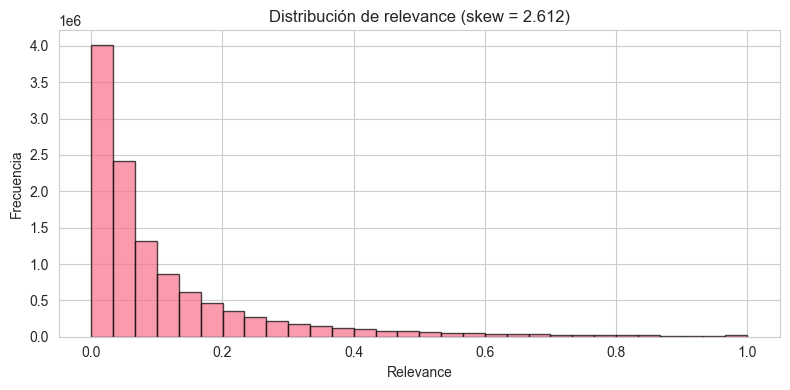

In [12]:
# Relevancia (genome_scores)
skew_rel = stats.skew(genome_scores['relevance'])
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(genome_scores['relevance'], bins=30, edgecolor='black', alpha=0.7)
ax.set_xlabel('Relevance')
ax.set_ylabel('Frecuencia')
ax.set_title(f'Distribución de relevance (skew = {skew_rel:.3f})')
plt.tight_layout()
plt.show()

### Distribución de actividad de usuarios y participación en el total de ratings
Gráfica tipo MovieLens: barras = cantidad de usuarios por nivel de actividad; verde = participación (% del total de ratings).

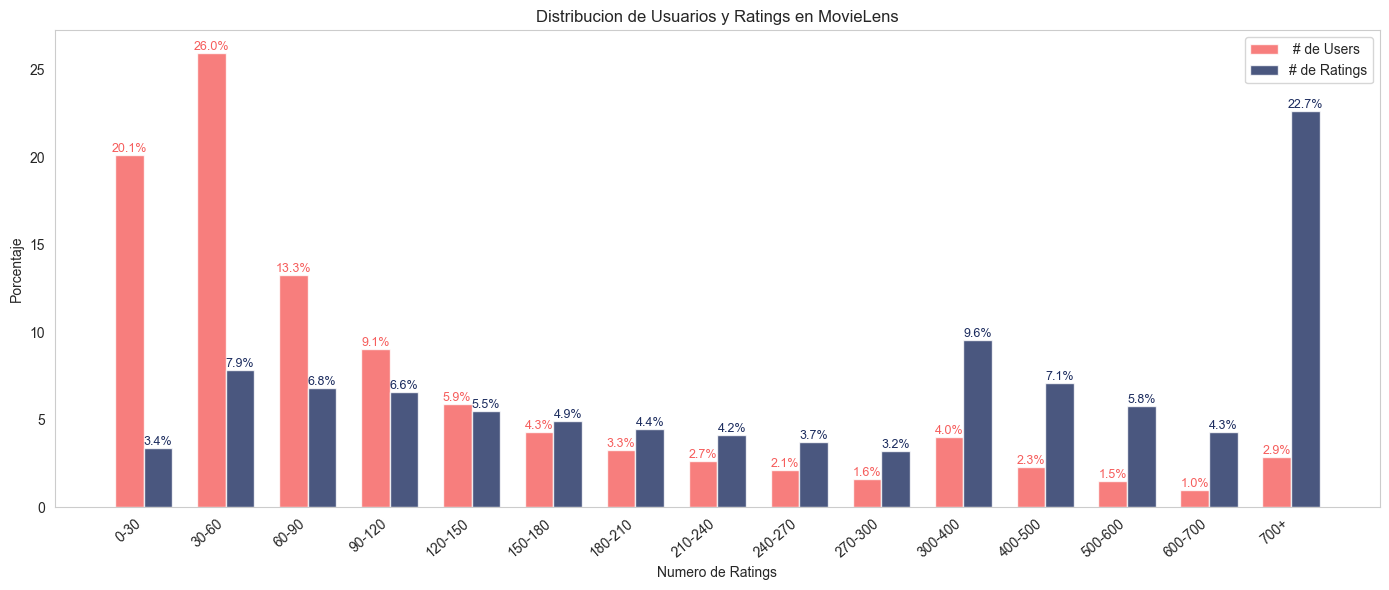

(<Figure size 1400x600 with 1 Axes>,
 <Axes: title={'center': 'Distribucion de Usuarios y Ratings en MovieLens'}, xlabel='Numero de Ratings', ylabel='Porcentaje'>)

In [13]:
from typing import Any


def plot_user_rating_distribution(rating_df, user_id_col="userId", title="", figsize=(14, 6)):
    #Creacion de los bins, y los labels. Primero en conjuntos de 30 y luego de 100. Se logran 15 bins
    e30 = list(range(0, 301, 30))
    e100 = [400, 500, 600, 700]
    bins = e30 + e100 + [np.inf]
    labels = [f"{e30[i]}-{e30[i+1]}" for i in range(len(e30)-1)] + ["300-400"] + [f"{e100[i]}-{e100[i+1]}" for i in range(len(e100)-1)] + ["700+"]

    ratings_per_user = rating_df.groupby(user_id_col).size()
    ub = pd.cut(ratings_per_user, bins=bins, labels=labels, include_lowest=True)
    n_users = ub.value_counts().sort_index().reindex(labels, fill_value=0)
    n_ratings = rating_df.merge(ub.rename("bin"), left_on=user_id_col, right_index=True).groupby("bin", observed=True).size().reindex(labels, fill_value=0)
    pct_u = 100 * n_users / n_users.sum()
    pct_r = 100 * n_ratings / n_ratings.sum()

    x = np.arange(len(labels))
    w = 0.35
    fig, ax = plt.subplots(figsize=figsize)
    for pct, dx, color, lab in [(pct_u, -w/2, "#F65E5D", " # de Users"), (pct_r, w/2, "#1D2D5F", "# de Ratings")]:
        ax.bar(x + dx, pct, w, label=lab, color=color, alpha=0.8)
        for i, v in enumerate(pct):
            if v > 0:
                ax.annotate(f"{v:.1f}%", (x[i] + dx, v), ha="center", va="bottom", fontsize=9, color=color)

    ax.set_xlabel("Numero de Ratings")
    ax.set_ylabel("Porcentaje")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=40, ha="right")
    ax.grid(False)
    ax.legend(loc="upper right")
    plt.title(title)
    plt.tight_layout()
    plt.show()
    return fig, ax

plot_user_rating_distribution(rating, title="Distribucion de Usuarios y Ratings en MovieLens", figsize=(14, 6))

En la anterior grafica podemos apreciar facilmente la distribucion general de los ratings:

Por ejemplo el primer conjunto de barras nos indica que el 20% de los usuarios ha calificado entre 0 y 30 peliculas, lo que corresponde a un 3.4% del total de las calificaciones.


# 2.Pre procesamiento de los datos

### 2.1 Seleccion de la muestra representativa

Primero se realiza una muestra utilizando un shuffle de varias veces y posteriormente se selecciona un porcentaje de los datos.

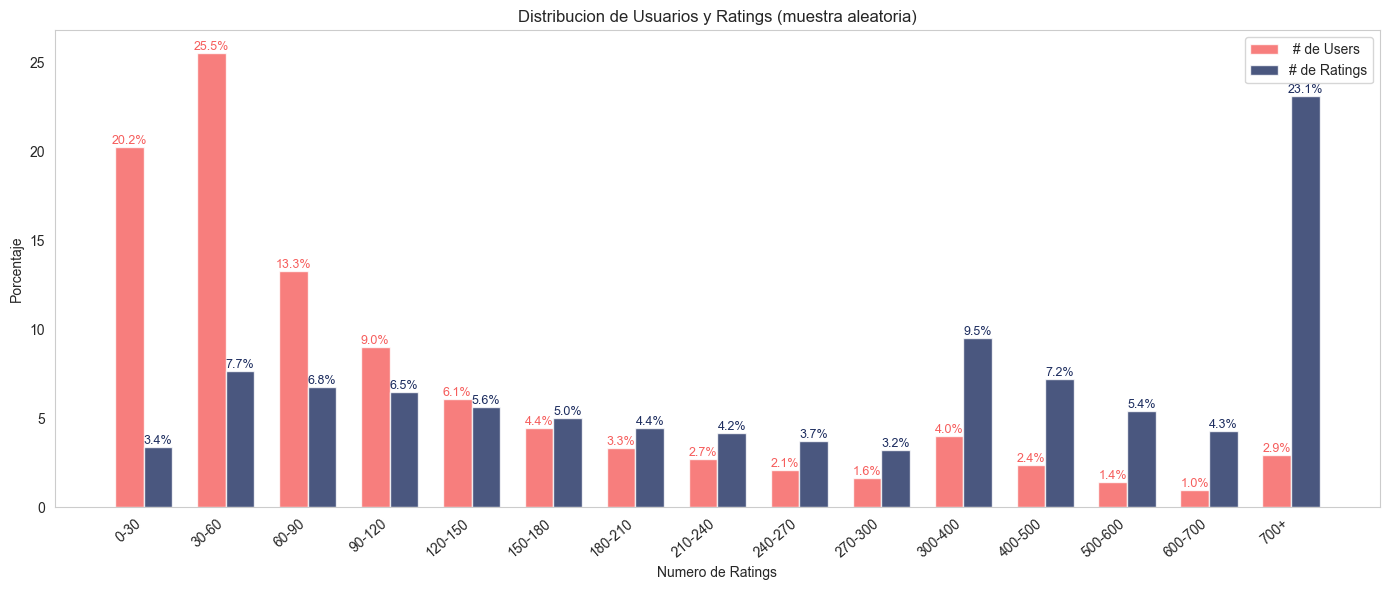

(<Figure size 1400x600 with 1 Axes>,
 <Axes: title={'center': 'Distribucion de Usuarios y Ratings (muestra aleatoria)'}, xlabel='Numero de Ratings', ylabel='Porcentaje'>)

In [14]:
# Semilla para reproducibilidad estocástica
RANDOM_SEED = 505
#Porcentaje de la muestra
SAMPLE_SIZE = 0.3

# Comparacion contra Muestra aleatoria
rating_aleatorio = rating.copy()

# Shuffle del dataframe 7 veces (usando RANDOM_SEED + i para reproducibilidad)
#rating_aleatorio = rating_aleatorio.sample(frac=1, random_state=RANDOM_SEED )

# Subconjunto de usuarios elegidos de forma aleatoria con RANDOM_SEED
rng = np.random.default_rng(RANDOM_SEED)
unique_users = rating_aleatorio["userId"].unique()
n_users_select = max(1, int(round(SAMPLE_SIZE * len(unique_users))))
selected_users_aleatorio = rng.choice(unique_users, size=n_users_select, replace=False)
rating_aleatorio = rating_aleatorio[rating_aleatorio["userId"].isin(selected_users_aleatorio)]

# Grafica de distribucion con la muestra aleatoria
plot_user_rating_distribution(rating_aleatorio, title="Distribucion de Usuarios y Ratings (muestra aleatoria)", figsize=(14, 6))

Ahora se realiza un muestreo con la tecnica de Muestreo Estratificado:

In [15]:
#Ratings por user
ratings_per_user = rating.groupby("userId").size()

# Estratificación: grupos por cantidad de ratings (0-100, 101-200, 201-300, ...)
max_ratings = int(ratings_per_user.max())
bins_strata = list(range(0, max_ratings + 101, 100)) + [np.inf]  # bordes: 0, 100, 200, ..., inf
user_stratum = pd.cut(ratings_per_user, bins=bins_strata, include_lowest=True)

# DataFrame usuario -> estrato (para agrupar y muestrear)
users_with_stratum = ratings_per_user.reset_index(name="n_ratings")
users_with_stratum["stratum"] = user_stratum

# Resumen de estratos
print("Estratos (por cantidad de ratings por usuario):")
print(users_with_stratum["stratum"].value_counts().sort_index())

Estratos (por cantidad de ratings por usuario):
stratum
(-0.001, 100.0]     86624
(100.0, 200.0]      25270
(200.0, 300.0]      10415
(300.0, 400.0]       5545
(400.0, 500.0]       3197
                    ...  
(8900.0, 9000.0]        0
(9000.0, 9100.0]        0
(9100.0, 9200.0]        0
(9200.0, 9300.0]        1
(9300.0, inf]           0
Name: count, Length: 94, dtype: int64


In [ ]:
# Por cada estrato: muestrear 30% de usuarios
# Si el estrato tiene pocos usuarios, tomar al menos 1 si hay al menos 1
selected_user_ids = []
for stratum_idx, (stratum_id, group) in enumerate(users_with_stratum.groupby("stratum", observed=True)):
    user_ids = group["userId"].tolist()
    n = len(user_ids)
    n_sample = max(1, int(round(SAMPLE_SIZE * n))) if n > 0 else 0
    if n_sample > 0:
        # Semilla distinta por estrato para reproducibilidad
        rng = np.random.default_rng(RANDOM_SEED + stratum_idx)
        idx = rng.choice(n, size=min(n_sample, n), replace=False)
        selected = [user_ids[i] for i in idx]
        selected_user_ids.extend(selected)

selected_user_ids = list(selected_user_ids)
print(f"Usuarios seleccionados: {len(selected_user_ids):,} de {len(users_with_stratum):,} total")
print(f"Fracción aproximada: {100*len(selected_user_ids)/len(users_with_stratum):.1f}%")

Usuarios seleccionados: 41,562 de 138,493 total
Fracción aproximada: 30.0%


In [17]:
# Nuevo conjunto de datos: solo usuarios seleccionados y películas que aparecen en la muestra
selected_set = set(selected_user_ids)

rating_sample = rating[rating["userId"].isin(selected_set)].copy()
tag_sample = tag[tag["userId"].isin(selected_set)].copy()

# Películas que tienen al menos un rating en la muestra
movie_ids_in_sample = rating_sample["movieId"].unique()
movie_sample = movie[movie["movieId"].isin(movie_ids_in_sample)].copy()
link_sample = link[link["movieId"].isin(movie_sample["movieId"])].copy()
genome_scores_sample = genome_scores[genome_scores["movieId"].isin(movie_sample["movieId"])].copy()

# Resumen: filas original vs muestra
print("Resumen de la muestra representativa:")
print(f"  rating:        {len(rating):,} -> {len(rating_sample):,} filas")
print(f"  tag:           {len(tag):,} -> {len(tag_sample):,} filas")
print(f"  movie:         {len(movie):,} -> {len(movie_sample):,} filas")
print(f"  link:          {len(link):,} -> {len(link_sample):,} filas")
print(f"  genome_scores: {len(genome_scores):,} -> {len(genome_scores_sample):,} filas")
print(f"  genome_tags:   (sin filtrar) {len(genome_tags):,} filas")

Resumen de la muestra representativa:
  rating:        20,000,263 -> 5,996,602 filas
  tag:           465,564 -> 134,908 filas
  movie:         27,278 -> 22,542 filas
  link:          27,278 -> 22,542 filas
  genome_scores: 11,709,768 -> 11,681,568 filas
  genome_tags:   (sin filtrar) 1,128 filas


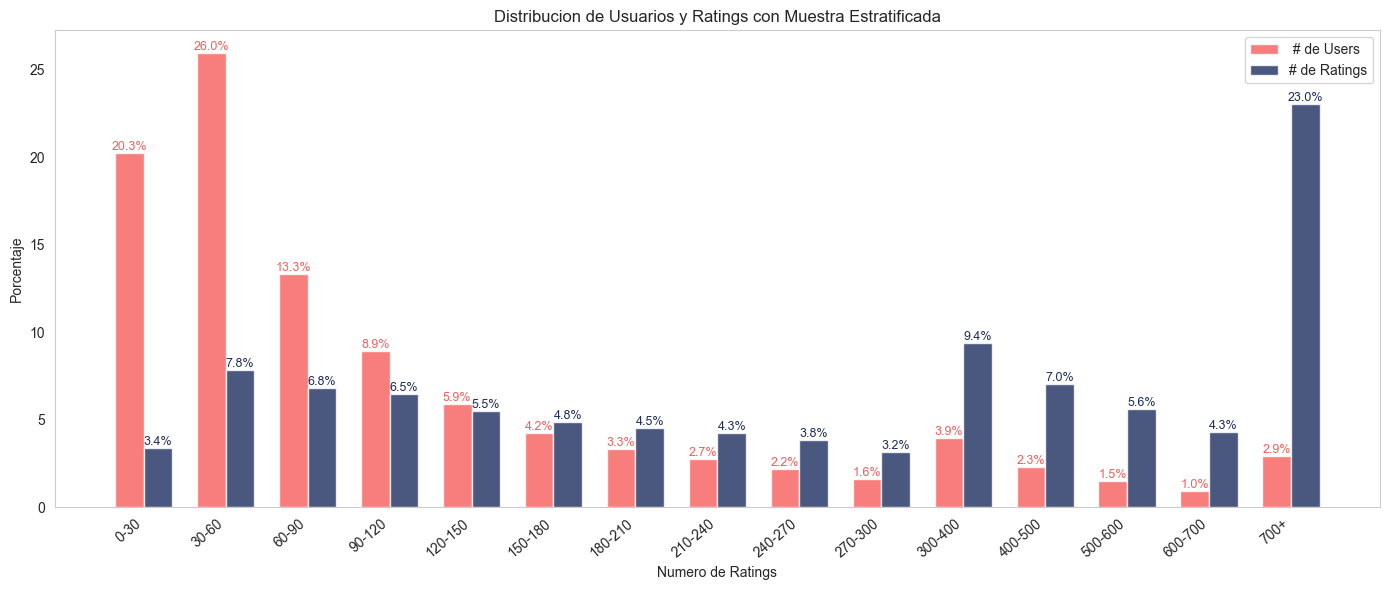

(<Figure size 1400x600 with 1 Axes>,
 <Axes: title={'center': 'Distribucion de Usuarios y Ratings con Muestra Estratificada'}, xlabel='Numero de Ratings', ylabel='Porcentaje'>)

In [18]:
plot_user_rating_distribution(rating_sample, title="Distribucion de Usuarios y Ratings con Muestra Estratificada", figsize=(14, 6))

Por rigor academico se decide elegir el dataset que utiliza el Muestreo Estratificado. 

## 2.2 Division del Dataset

In [19]:
# Eliminar los df que no se usan para liberar memoria.
del rating
del tag
del movie
del link
del genome_scores
del rating_aleatorio
# genome_tags se mantiene, ya que no fue filtrado


In [20]:
#Split del dataset en Test y Train
from sklearn.model_selection import train_test_split

# Realiza el split de 70% train y 30% test usando la misma semilla
train_set, test_set = train_test_split(
    rating_sample,
    test_size=0.3,
    random_state=RANDOM_SEED
)

print(f"Tamaño del set de entrenamiento: {len(train_set):,}")
print(f"Tamaño del set de prueba: {len(test_set):,}")

Tamaño del set de entrenamiento: 4,197,621
Tamaño del set de prueba: 1,798,981
